In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

one can use tickers from ticker_list=['AAPL','MSFT','AMZN','GOOGL','META','TSLA','NVDA','GS','KO','PEP']
note i have selected apple


In [ ]:
df=yf.download('AAPL',start='2020-01-01',end='2025-01-01')

/tmp/ipython-input-2866032257.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download('AAPL',start='2020-01-01',end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468254,72.528574,71.223252,71.476592,135480400
2020-01-03,71.763718,72.523746,71.539330,71.696160,146322800
2020-01-06,72.335571,72.374177,70.634554,70.885487,118387200
2020-01-07,71.995361,72.600968,71.775796,72.345212,108872000
2020-01-08,73.153511,73.455110,71.698596,71.698596,132079200


In [ ]:
!unzip "archive (3).zip"

Archive:  archive (3).zip
  inflating: cnbc_headlines.csv      
  inflating: guardian_headlines.csv  
  inflating: reuters_headlines.csv   


In [ ]:
cnbc=pd.read_csv("cnbc_headlines.csv")
guardian=pd.read_csv("guardian_headlines.csv")
reuters=pd.read_csv("reuters_headlines.csv")


In [ ]:
cnbc.columns,guardian.columns,reuters.columns

(Index(['Headlines', 'Time', 'Description'], dtype='object'),
 Index(['Time', 'Headlines'], dtype='object'),
 Index(['Headlines', 'Time', 'Description'], dtype='object'))

In [ ]:
def standardize(dlf):
    dlf=dlf.copy()
    dlf=dlf.rename(columns={
        'Headlines':'text',
        'Time':'date'
    })
    return dlf[['date', 'text']]

In [ ]:
cnbc_std=standardize(cnbc)
guardian_std=standardize(guardian)
reuters_std=standardize(reuters)

In [ ]:
news_df=pd.concat(
    [cnbc_std,guardian_std,reuters_std],
    ignore_index=True
)

news_df.head()

,date,text
0,"7:51 PM ET Fri, 17 July 2020",Jim Cramer: A better way to invest in the Covi...
1,"7:33 PM ET Fri, 17 July 2020",Cramer's lightning round: I would own Teradyne
2,NaN,NaN
3,"7:25 PM ET Fri, 17 July 2020","Cramer's week ahead: Big week for earnings, ev..."
4,"4:24 PM ET Fri, 17 July 2020",IQ Capital CEO Keith Bliss says tech and healt...


In [ ]:
import datetime as dt
news_df=news_df.dropna(subset=['text'])

news_df['date']=pd.to_datetime(
    news_df['date'],
    errors='coerce'
).dt.date

news_df=news_df.dropna(subset=['date'])
news_df.head()

,date,text
0,2020-07-17,Jim Cramer: A better way to invest in the Covi...
1,2020-07-17,Cramer's lightning round: I would own Teradyne
3,2020-07-17,"Cramer's week ahead: Big week for earnings, ev..."
4,2020-07-17,IQ Capital CEO Keith Bliss says tech and healt...
5,2020-07-16,Wall Street delivered the 'kind of pullback I'...


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

news_df['sentiment']=news_df['text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

news_df.head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,date,text,sentiment
0,2020-07-17,Jim Cramer: A better way to invest in the Covi...,0.4404
1,2020-07-17,Cramer's lightning round: I would own Teradyne,0.0000
3,2020-07-17,"Cramer's week ahead: Big week for earnings, ev...",0.0000
4,2020-07-17,IQ Capital CEO Keith Bliss says tech and healt...,0.5719
5,2020-07-16,Wall Street delivered the 'kind of pullback I'...,0.0000


In [ ]:
daily_sentiment=(
    news_df
    .groupby('date')['sentiment']
    .mean()
    .reset_index()
)

daily_sentiment.head()

,date,sentiment
0,2017-12-17,0.028660
1,2017-12-18,-0.073070
2,2017-12-19,-0.179765
3,2017-12-20,0.000650
4,2017-12-21,0.050420


In [ ]:
df.columns=df.columns.get_level_values(0)

df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.468254,72.528574,71.223252,71.476592,135480400
2020-01-03,71.763718,72.523746,71.539330,71.696160,146322800
2020-01-06,72.335571,72.374177,70.634554,70.885487,118387200
2020-01-07,71.995361,72.600968,71.775796,72.345212,108872000
2020-01-08,73.153511,73.455110,71.698596,71.698596,132079200


In [ ]:
df_price=df.copy()
df_price['date']=df_price.index.date

In [ ]:
final_df=df_price.merge(
    daily_sentiment,
    on='date',
    how='left'
)

final_df['sentiment']=final_df['sentiment'].fillna(0)
final_df.head()

,Close,High,Low,Open,Volume,date,sentiment
0,72.468254,72.528574,71.223252,71.476592,135480400,2020-01-02,-0.011463
1,71.763718,72.523746,71.539330,71.696160,146322800,2020-01-03,-0.022213
2,72.335571,72.374177,70.634554,70.885487,118387200,2020-01-06,-0.086208
3,71.995361,72.600968,71.775796,72.345212,108872000,2020-01-07,-0.092992
4,73.153511,73.455110,71.698596,71.698596,132079200,2020-01-08,-0.020606


In [ ]:
final_df.head()

,Close,High,Low,Open,Volume,date,sentiment
0,72.468254,72.528574,71.223252,71.476592,135480400,2020-01-02,-0.011463
1,71.763718,72.523746,71.539330,71.696160,146322800,2020-01-03,-0.022213
2,72.335571,72.374177,70.634554,70.885487,118387200,2020-01-06,-0.086208
3,71.995361,72.600968,71.775796,72.345212,108872000,2020-01-07,-0.092992
4,73.153511,73.455110,71.698596,71.698596,132079200,2020-01-08,-0.020606


In [ ]:
def add_indicators(final_df):
    final_df=final_df.copy()

    final_df['return']=final_df['Close'].pct_change().fillna(0)
    final_df['ema_20']=final_df['Close'].ewm(span=20,adjust=False).mean()
    final_df['ema_50']=final_df['Close'].ewm(span=50,adjust=False).mean()

    delta=final_df['Close'].diff().fillna(0)
    up=np.where(delta>0,delta,0)
    down=np.where(delta<0,-delta,0)

    rolling_up=pd.Series(up,index=final_df.index).rolling(14).mean()
    rolling_down=pd.Series(down,index=final_df.index).rolling(14).mean()

    rs=rolling_up/(rolling_down+1e-9)
    final_df['rsi_14']=100-(100/(1+rs))
    final_df['rsi_14']=final_df['rsi_14'].fillna(50)

    return final_df

In [ ]:
final_df=add_indicators(final_df)
final_df=final_df.dropna().copy()
final_df.tail()

,Close,High,Low,Open,Volume,date,sentiment,return,ema_20,ema_50,rsi_14
1253,257.037506,257.047440,254.140589,254.339701,23234700,2024-12-24,0.0,0.011478,245.557885,237.232258,76.180666
1254,257.853760,258.928914,256.470034,257.027510,27237100,2024-12-26,0.0,0.003176,246.728921,238.040944,76.812091
1255,254.439224,257.535238,251.920617,256.669129,42355300,2024-12-27,0.0,-0.013242,247.463235,238.684014,69.300674
1256,251.064484,252.358634,249.621015,251.094347,35557500,2024-12-30,0.0,-0.013263,247.806211,239.169523,58.382029
1257,249.292511,252.139635,248.306963,251.303420,39480700,2024-12-31,0.0,-0.007058,247.947764,239.566503,53.982588


In [ ]:
final_df.head()

,Close,High,Low,Open,Volume,date,sentiment,return,ema_20,ema_50,rsi_14
0,72.468254,72.528574,71.223252,71.476592,135480400,2020-01-02,-0.011463,0.000000,72.468254,72.468254,50.0
1,71.763718,72.523746,71.539330,71.696160,146322800,2020-01-03,-0.022213,-0.009722,72.401155,72.440625,50.0
2,72.335571,72.374177,70.634554,70.885487,118387200,2020-01-06,-0.086208,0.007969,72.394909,72.436505,50.0
3,71.995361,72.600968,71.775796,72.345212,108872000,2020-01-07,-0.092992,-0.004703,72.356857,72.419206,50.0
4,73.153511,73.455110,71.698596,71.698596,132079200,2020-01-08,-0.020606,0.016086,72.432729,72.448002,50.0


In [ ]:
features=['Close','Volume','sentiment','ema_20','ema_50','return','rsi_14']
final_df=final_df[features].copy()
final_df.shape

(1258, 7)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
target_scaler=MinMaxScaler()
scaled=scaler.fit_transform(final_df)
scaled_df=pd.DataFrame(scaled, index=final_df.index, columns=final_df.columns)
y_scaled=target_scaler.fit_transform(final_df[['Close']])
scaled_df.head()

,Close,Volume,sentiment,ema_20,ema_50,return,rsi_14
0,0.089415,0.278335,0.714980,0.057761,0.036908,0.517787,0.503534
1,0.085954,0.305221,0.667435,0.057401,0.036749,0.478657,0.503534
2,0.088763,0.235949,0.384413,0.057367,0.036725,0.549860,0.503534
3,0.087092,0.212354,0.354408,0.057163,0.036626,0.498857,0.503534
4,0.092781,0.269901,0.674542,0.057570,0.036792,0.582533,0.503534


In [ ]:
def create_windows(data_arr, window):
    X,y_reg,y_clf =[], [], []
    n=len(data_arr)
    for i in range(n-window ):
        x=data_arr[i:i+window]
        y_next=data_arr[i+window][0]
        curr_close=data_arr[i+window-1][0]
        y_label = 1 if y_next > curr_close else 0
        X.append(x)
        y_reg.append(y_next)
        y_clf.append(y_label)
    return np.array(X),np.array(y_reg),np.array(y_clf)

X,y_reg,y_clf=create_windows(scaled_df.values,60)

In [ ]:
X.shape,y_reg.shape,y_clf.shape

((1198, 60, 7), (1198,), (1198,))

In [ ]:
split=1198*0.8

In [ ]:
split

958.4000000000001

In [ ]:
x_train=X[:958]
x_test=X[958:]
y_reg_train=y_reg[:958]
y_reg_test=y_reg[958:]
y_clf_train=y_clf[:958]
y_clf_test=y_clf[958:]

In [ ]:
x_train.shape,x_test.shape,y_reg_train.shape,y_reg_test.shape,y_clf_train.shape,y_clf_test.shape

((958, 60, 7), (240, 60, 7), (958,), (240,), (958,), (240,))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout
model=Sequential([LSTM(128,return_sequences=True,input_shape=(60,7)),
                  Dropout(0.2),
                  LSTM(64,return_sequences=True),
                  Dropout(0.1),
                  LSTM(64,return_sequences=True),
                  Dropout(0.1),
                  LSTM(32),
                  Dense(32,activation='relu'),
                  Dense(1,activation='linear')])





/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,569 (646.75 KB)

 Trainable params: 165,569 (646.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
callbacks=EarlyStopping(monitor='val_loss',patience=20,restore_best_weights=True)

In [ ]:
model.compile(loss='mse',optimizer='adam',metrics=['mse'])

In [ ]:
history=model.fit(x_train,y_reg_train,epochs=30,batch_size=32,validation_split=0.2,callbacks=callbacks)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - loss: 0.0072 - mse: 0.0072 - val_loss: 0.0031 - val_mse: 0.0031
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - loss: 0.0023 - mse: 0.0023 - val_loss: 0.0045 - val_mse: 0.0045
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0021 - val_mse: 0.0021
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - loss: 0.0015 - mse: 0.0015 - val_loss: 0.0011 - val_mse: 0.0011
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 0.0017 - val_mse: 0.0017
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - loss: 0.0016 - mse: 0.0016 - val_loss: 0.0018 - val_mse: 0.0018
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - loss: 0.0013 - mse: 0.0013 - val_loss: 0.0016 - val_mse: 0.0016
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - loss: 0.0011 - mse: 0.0011 - val_loss: 8.8999e-04 - val_mse: 8.8999e-04
Epoch 9/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/

Text(0, 0.5, 'loss')

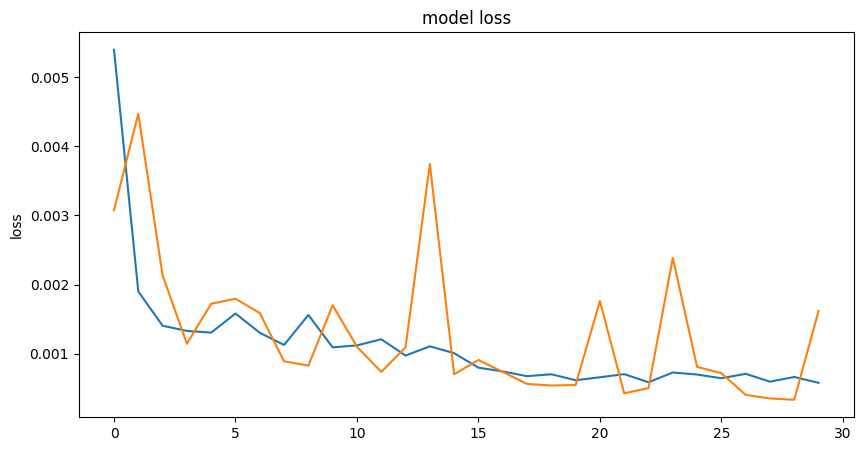

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')

Text(0, 0.5, 'mse')

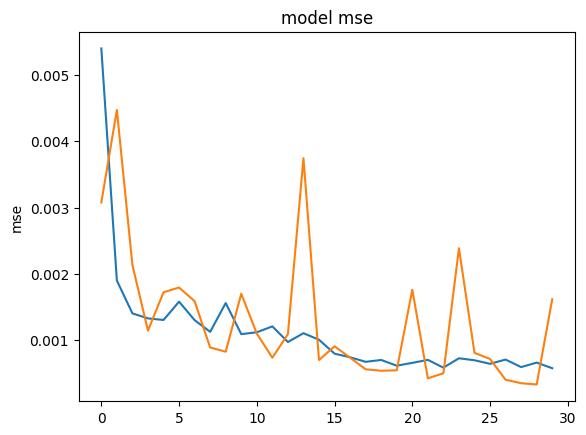

In [ ]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model mse')
plt.ylabel('mse')

In [ ]:
pred_scaled=model.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step


In [ ]:
pred_scaled[0]

array([0.6213502], dtype=float32)

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score

In [ ]:
msee=mean_squared_error(y_reg_test,pred_scaled)

In [ ]:
msee

0.00331391575680131

In [ ]:
pred_close = target_scaler.inverse_transform(pred_scaled)

In [ ]:
pred_close[0]

array([180.76466], dtype=float32)

In [ ]:
y_reg_test[0]

np.float64(0.6655724762115225)

In [ ]:
y_reg_real=target_scaler.inverse_transform(y_reg_test.reshape(-1,1))

In [ ]:
y_reg_real[0]

array([189.76785278])

In [ ]:
pred_close[2]

array([182.2963], dtype=float32)

In [ ]:
y_reg_real[2]

array([193.35397339])

In [ ]:
pred_close[122]

array([212.65376], dtype=float32)

In [ ]:
y_reg_real[122]

array([233.23588562])

In [ ]:
mseee=mean_squared_error(y_reg_real,pred_close)

In [ ]:
mseee

137.35723539676792

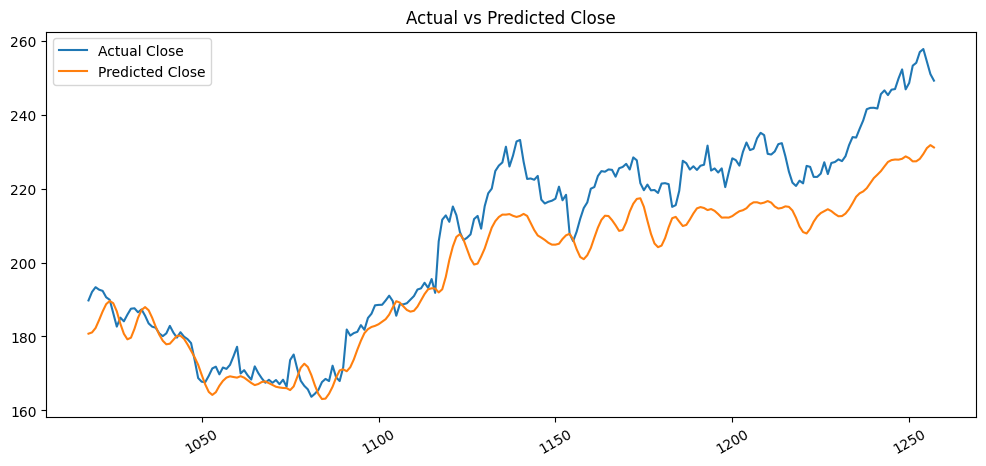

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(dates_test, y_reg_real, label='Actual Close')
plt.plot(dates_test, pred_close, label='Predicted Close')
plt.legend(); plt.title("Actual vs Predicted Close")
plt.xticks(rotation=30)
plt.show()

In [ ]:
def mc_dropout_predict(model,X,n_iter=50):
    preds=[]
    for _ in range(n_iter):
        pred=model(X,training=True)
        preds.append(pred.numpy())
    preds=np.array(preds)

    mean=preds.mean(axis=0)
    std=preds.std(axis=0)
    return mean, std

In [ ]:
mc_mean_scaled,mc_std_scaled=mc_dropout_predict(model, x_test, n_iter=50)

mc_mean_real=target_scaler.inverse_transform(mc_mean_scaled)

price_range=target_scaler.data_max_ - target_scaler.data_min_
mc_std_real=mc_std_scaled*price_range
upper=mc_mean_real+1.96*mc_std_real
lower=mc_mean_real-1.96*mc_std_real

In [ ]:
y_reg_real=y_reg_real.flatten()
mc_mean_real=mc_mean_real.flatten()
upper=upper.flatten()
lower=lower.flatten()

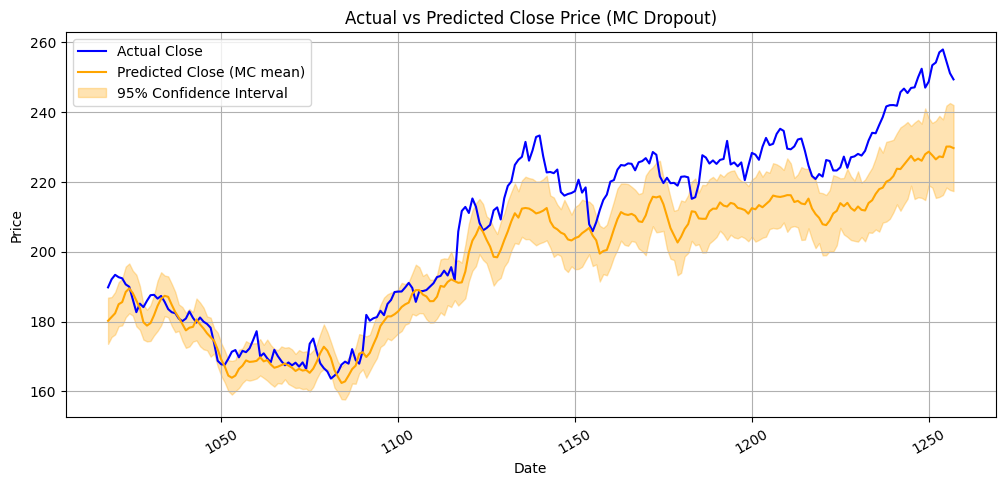

In [ ]:
plt.figure(figsize=(12,5))


plt.plot(dates_test,y_reg_real,label="Actual Close",color="blue")


plt.plot(dates_test,mc_mean_real,label="Predicted Close (MC mean)",color="orange")

plt.fill_between(
    dates_test,
    lower,
    upper,
    color="orange",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("Actual vs Predicted Close Price (MC Dropout)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=30)
plt.grid(True)

plt.show()

In [ ]:
model2=Sequential([LSTM(128,return_sequences=True,input_shape=(60,7)),
                   Dropout(0.2),
                   LSTM(128,return_sequences=True),
                   Dropout(0.2),
                   LSTM(64),
                   Dense(32,activation='relu'),
                   Dense(1,activation='sigmoid')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,737 (987.25 KB)

 Trainable params: 252,737 (987.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
callbacks2=EarlyStopping(monitor='val_loss',patience=20,restore_best_weights=True)

In [ ]:
history2=model2.fit(x_train,y_clf_train,epochs=30,validation_split=0.2,callbacks=callbacks2,batch_size=32)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 310ms/step - accuracy: 0.5055 - loss: 0.6944 - val_accuracy: 0.5312 - val_loss: 0.6918
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.5057 - loss: 0.6905 - val_accuracy: 0.5312 - val_loss: 0.6912
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.5119 - loss: 0.6936 - val_accuracy: 0.5312 - val_loss: 0.6917
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.5320 - loss: 0.6910 - val_accuracy: 0.5312 - val_loss: 0.6918
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 296ms/step - accuracy: 0.4950 - loss: 0.6948 - val_accuracy: 0.5312 - val_loss: 0.6916
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.5020 - loss: 0.6959 - val_accuracy: 0.4583 - val_loss: 0.6949
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 223ms/step - accuracy: 0.5475 - loss: 0.6850 - val_accuracy: 0.4688 - val_loss: 0.6961
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - accuracy: 0.4946 - loss: 0.6929 - val_accuracy: 

Text(0, 0.5, 'loss')

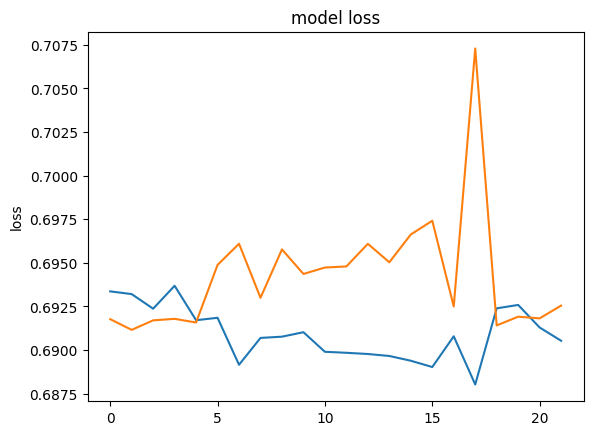

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')

Text(0, 0.5, 'accuracy')

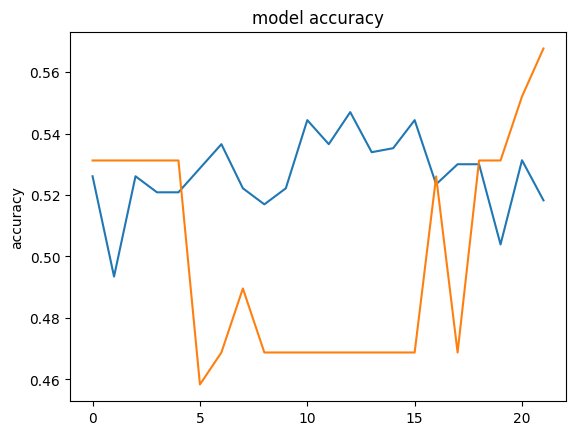

In [ ]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')

In [ ]:
pred_clf=model2.predict(x_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step


In [ ]:
pred_clf[0]

array([0.52609026], dtype=float32)

In [ ]:
pred_clf_labels=np.where(pred_clf>0.5,1,0)

In [ ]:
acc=accuracy_score(y_clf_test,pred_clf_labels)

In [ ]:
acc

0.575

In [ ]:
strategy=np.zeros(len(y_reg_real))
for i in range (len(y_reg_real)-1):
  if(y_reg_real[i+1]>y_reg_real[i]):
    strategy[i]=1

In [ ]:
returns=np.zeros(len(y_reg_real))
for i in range(len(y_reg_real)-1):
  returns[i]=(y_reg_real[i+1]-y_reg_real[i])/y_reg_real[i]


In [ ]:
strategic_returns=returns*strategy

In [ ]:
initial_capital=100000

portfolio=[initial_capital]

for r in strategic_returns:
    portfolio.append(portfolio[-1]*(1+r))

portfolio=np.array(portfolio[:-1])

In [ ]:
buy_hold=initial_capital*(y_reg_real/y_reg_real[0])

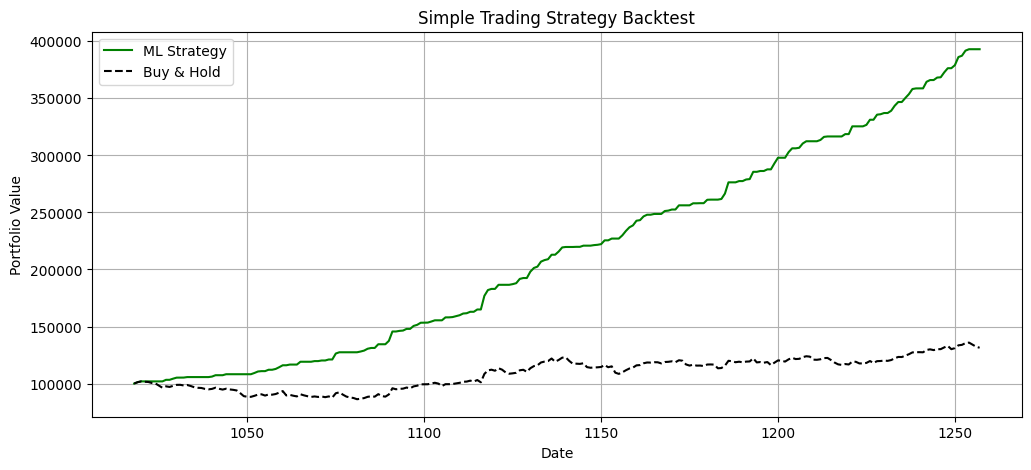

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(dates_test,portfolio,label="ML Strategy",color="green")
plt.plot(dates_test,buy_hold,label="Buy & Hold",color="black",linestyle="--")

plt.title("Simple Trading Strategy Backtest")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()